In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Fix TotalCharges — string hai, float banana hai
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Null rows drop karo
df.dropna(inplace=True)

# Churn ko 0/1 mein convert karo
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# customerID drop karo
df.drop('customerID', axis=1, inplace=True)

print(f"After cleaning: {df.shape}")
print(f"Null values: {df.isnull().sum().sum()}")
print(f"Churn distribution:\n{df['Churn'].value_counts()}")

After cleaning: (7032, 20)
Null values: 0
Churn distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


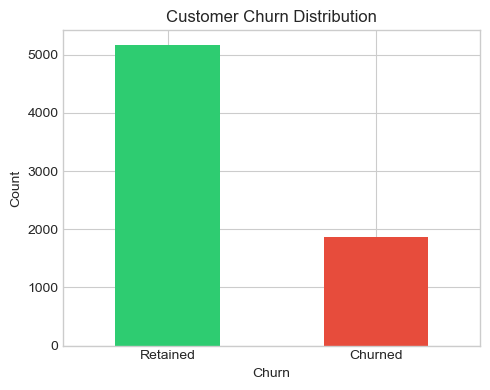

Churn Rate: 26.6%


In [4]:
# Churn rate bar chart
fig, ax = plt.subplots(figsize=(5, 4))
df['Churn'].value_counts().plot(
    kind='bar', ax=ax,
    color=['#2ecc71', '#e74c3c'],
    edgecolor='none'
)
ax.set_xticklabels(['Retained', 'Churned'], rotation=0)
ax.set_title('Customer Churn Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Churn Rate: {df['Churn'].mean()*100:.1f}%")

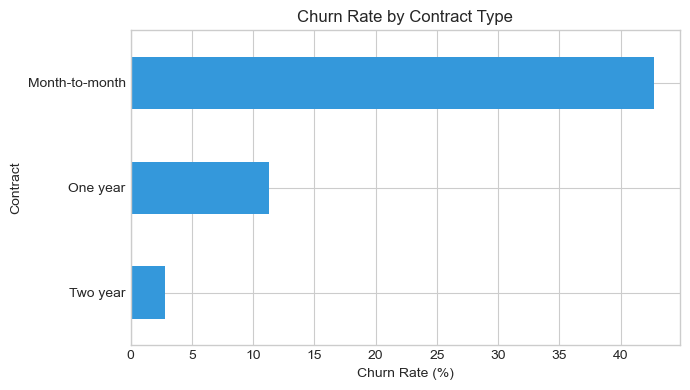

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
contract_churn = df.groupby('Contract')['Churn'].mean() * 100
contract_churn.sort_values().plot(kind='barh', ax=ax, color='#3498db')
ax.set_xlabel('Churn Rate (%)')
ax.set_title('Churn Rate by Contract Type')
plt.tight_layout()
plt.show()

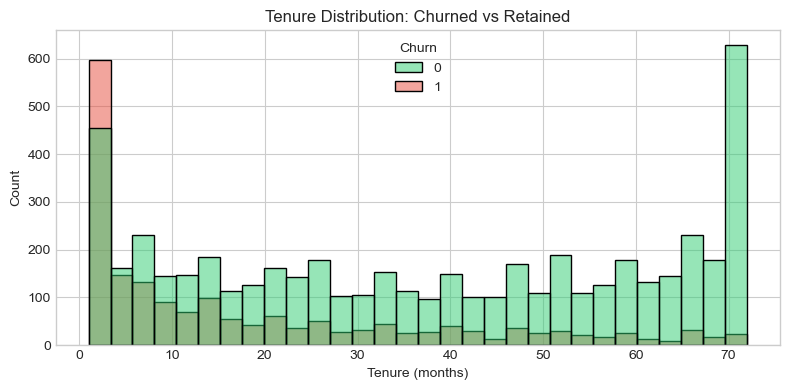

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(
    data=df, x='tenure', hue='Churn',
    bins=30, ax=ax,
    palette={0: '#2ecc71', 1: '#e74c3c'}
)
ax.set_title('Tenure Distribution: Churned vs Retained')
ax.set_xlabel('Tenure (months)')
plt.tight_layout()
plt.show()

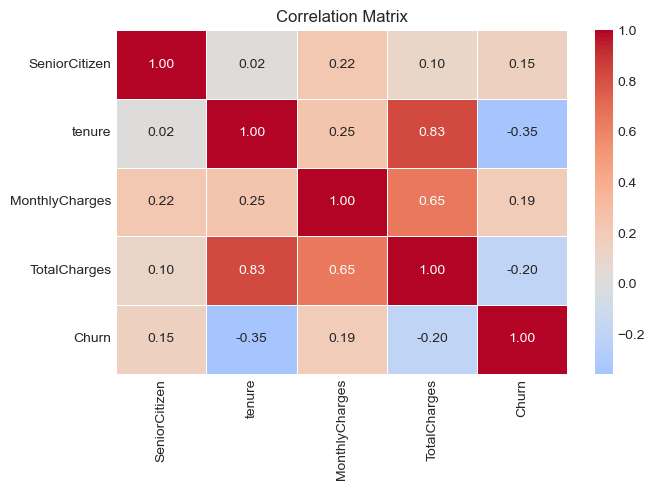

In [7]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    ax=ax, linewidths=0.5
)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [8]:
print("=== EDA KEY INSIGHTS ===")
print(f"Overall Churn Rate: {df['Churn'].mean()*100:.1f}%")
print(f"Avg tenure (churned): {df[df['Churn']==1]['tenure'].mean():.0f} months")
print(f"Avg tenure (retained): {df[df['Churn']==0]['tenure'].mean():.0f} months")
print(f"Avg MonthlyCharges (churned): ${df[df['Churn']==1]['MonthlyCharges'].mean():.1f}")
print(f"Avg MonthlyCharges (retained): ${df[df['Churn']==0]['MonthlyCharges'].mean():.1f}")

=== EDA KEY INSIGHTS ===
Overall Churn Rate: 26.6%
Avg tenure (churned): 18 months
Avg tenure (retained): 38 months
Avg MonthlyCharges (churned): $74.4
Avg MonthlyCharges (retained): $61.3
